# SND@LHC SciFi Multi-Parameter Calibration: 3D Parameter Space Exploration & Optimization
## Advanced Multi-Objective Visualization, Tomographic Slicing, Profile Likelihood, and Pareto Frontier Analysis

### 1. Scientific Motivation & Theoretical Framework
In the **SND@LHC** experiment at the CERN Large Hadron Collider, the Target Tracking System (SciFi) comprises 5 stations with 10 planes of scintillating fibers readout by Silicon Photomultipliers (SiPMs). To faithfully reproduce collision data distributions for single muon and trident backgrounds, Monte Carlo simulations must accurately emulate two coupled physical processes:
1. **Hit Detection Multiplicity**: The SiPM hit detection threshold $t_s$ (in photo-electrons, $\text{p.e.}$) determines discrete fiber detection efficiency, noise cluster rejection, and overall track hit multiplicity.
2. **Hit Energy Deposition (QDC)**: The raw digitized charge follows a Landau-Gaussian energy loss distribution. Emulating data requires an empirical linear calibration transformation:
   $$x_{\text{calib}} = \frac{x_{\text{raw}} - b_0}{s_{\text{QDC}}}$$
   where $s_{\text{QDC}}$ is the calibration scale factor and $b_0$ is the pedestal/electronic offset (in $\text{a.u.}$).

### 2. The 3D Parameter Space Challenge
The calibration optimization space is defined by three continuous dimensions $\boldsymbol{\theta} = (t_s, s_{\text{QDC}}, b_0)$. Evaluating high-density grids (e.g. 50,000 to 230,000 combinations) requires moving beyond naive 3D scatter plots to comprehensive diagnostic paradigms:
1. **Pairwise Profile "Corner Plot" Matrix**: Marginal profiles $\min \mathcal{L}$ on diagonals and 2D contour projections on off-diagonals.
2. **Multi-Slice Tomography (Small Multiples)**: Side-by-side 2D $(t_s, s_{\text{QDC}})$ loss surfaces sliced across discrete pedestal offsets $b_0$.
3. **Pareto Frontier Analysis**: Multi-objective trade-off curve balancing hit multiplicity fidelity ($W_1^{\text{hits}}$) against energy scale fidelity ($W_1^{\text{QDC}}$).
4. **Parallel Coordinates Trajectory Flow**: High-dimensional flow tracking how parameter choices govern metrics and composite loss.
5. **Calibrated Physics Overlays**: High-statistics distribution comparisons with ratio pull panels.
6. **Interactive Parameter Slicer**: Real-time dynamic response inspection via interactive widgets.

### 3. Quantitative Statistical Metrics
- **Wasserstein Distance ($W_1$, Earth Mover's Distance)**:
  $$W_1(P, Q) = \int_{-\infty}^{+\infty} |F_P(x) - F_Q(x)|\,dx$$
- **Joint Dimensionless Calibration Loss Function**:
  $$\mathcal{L}_{\text{total}}(t_s, s_{\text{QDC}}, b_0) = w_{\text{hits}} \left( \frac{W_1^{\text{hits}}}{\mu_{\text{data}}^{\text{hits}}} + \frac{\Delta_{\text{peak}}^{\text{hits}}}{x_{\text{peak, data}}^{\text{hits}}} \right) + w_{\text{QDC}} \left( \frac{W_1^{\text{QDC}}}{\mu_{\text{data}}^{\text{QDC}}} + \frac{\Delta_{\text{peak}}^{\text{QDC}}}{x_{\text{peak, data}}^{\text{QDC}}} \right)$$


In [1]:
import sys
import os
import time
import warnings
from pathlib import Path

# Suppress benign font and styling warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Dynamic repository root resolver
def get_repo_root() -> Path:
    """Finds repository root whether executed from notebooks/, root, or subdirectories."""
    curr = Path.cwd().resolve()
    for parent in [curr] + list(curr.parents):
        if (parent / "config" / "calibration_grid_config.yaml").exists():
            return parent
    return Path("/afs/cern.ch/work/i/idioniso/sndMuTri")

REPO_ROOT = get_repo_root()

# Add user custom library path
sys.path.insert(0, "/afs/cern.ch/user/i/idioniso")
sys.path.insert(0, str(REPO_ROOT))

import ROOT
import uproot
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import mplhep
import yaml

# Import custom user utilities
try:
    import ddfUtils.root as dr
    import ddfUtils.stats as ds
    from ddfUtils.mpl_styling import add_label
    has_ddf = True
except ImportError:
    has_ddf = False

# Configure ROOT and publication matplotlib style
plt.style.use("root")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Helvetica', 'Arial']
ROOT.gROOT.SetBatch(True)

print(f"[✓] Environment initialized successfully (Repo Root: {REPO_ROOT}, ddfUtils: {has_ddf}).")


[✓] Environment initialized successfully (Repo Root: /afs/cern.ch/work/i/idioniso/sndMuTri, ddfUtils: True).


In [2]:
# 1. Load Grid Configuration
CONFIG_PATH = REPO_ROOT / "config" / "calibration_grid_config.yaml"
assert CONFIG_PATH.exists(), f"Configuration file not found: {CONFIG_PATH}"

with open(CONFIG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

# 2. Load Collision Data References
hits_file_path = REPO_ROOT / cfg["data_reference"]["hits_file"]
qdc_file_path = REPO_ROOT / cfg["data_reference"]["qdc_file"]

assert hits_file_path.exists(), f"Collision data hits file not found: {hits_file_path}"
assert qdc_file_path.exists(), f"Collision data QDC file not found: {qdc_file_path}"

# Extract Data Hits Histogram
f_dh = ROOT.TFile.Open(str(hits_file_path))
h_data_hits = f_dh.Get(cfg["data_reference"]["hits_hist"])
assert h_data_hits, f"Missing histogram {cfg['data_reference']['hits_hist']} in {hits_file_path}"
h_data_hits.SetDirectory(0)
f_dh.Close()

# Extract Data QDC Histogram
f_dq = ROOT.TFile.Open(str(qdc_file_path))
h_data_qdc = f_dq.Get(cfg["data_reference"]["qdc_hist"])
assert h_data_qdc, f"Missing histogram {cfg['data_reference']['qdc_hist']} in {qdc_file_path}"
h_data_qdc.SetDirectory(0)
f_dq.Close()

# Extract Data Hits Observables
peak_data_hits = float(h_data_hits.GetBinCenter(h_data_hits.GetMaximumBin()))
mean_data_hits = float(h_data_hits.GetMean())
rms_data_hits = float(h_data_hits.GetRMS())
nbins_dh = h_data_hits.GetNbinsX()
x_edges_dh = np.array([h_data_hits.GetBinLowEdge(i) for i in range(1, nbins_dh + 2)])
dx_dh = float(h_data_hits.GetBinWidth(1))
counts_dh = np.array([h_data_hits.GetBinContent(i) for i in range(1, nbins_dh + 1)], dtype=np.float64)
sum_dh = float(np.sum(counts_dh))
cdf_dh = np.cumsum(counts_dh) / sum_dh

# Extract Data QDC Observables
peak_data_qdc = float(h_data_qdc.GetBinCenter(h_data_qdc.GetMaximumBin()))
mean_data_qdc = float(h_data_qdc.GetMean())
rms_data_qdc = float(h_data_qdc.GetRMS())
nbins_dq = h_data_qdc.GetNbinsX()
x_edges_dq = np.array([h_data_qdc.GetBinLowEdge(i) for i in range(1, nbins_dq + 2)])
dx_dq = float(h_data_qdc.GetBinWidth(1))
counts_dq = np.array([h_data_qdc.GetBinContent(i) for i in range(1, nbins_dq + 1)], dtype=np.float64)
sum_dq = float(np.sum(counts_dq))
cdf_dq = np.cumsum(counts_dq) / sum_dq

print("=" * 80)
print("SND@LHC COLLISION DATA BENCHMARKS LOADED")
print("=" * 80)
print(f"Hits Reference : {hits_file_path.name} [{cfg['data_reference']['hits_hist']}]")
print(f"  • Peak Hits  : {peak_data_hits:.1f} hits | Mean Hits: {mean_data_hits:.2f} hits | RMS: {rms_data_hits:.2f}")
print(f"QDC Reference  : {qdc_file_path.name} [{cfg['data_reference']['qdc_hist']}]")
print(f"  • Peak QDC   : {peak_data_qdc:.2f} a.u.  | Mean QDC : {mean_data_qdc:.2f} a.u.  | RMS: {rms_data_qdc:.2f}")
print("=" * 80)


SND@LHC COLLISION DATA BENCHMARKS LOADED
Hits Reference : passing_muon_selection.root [HitDistributions/SciFi_Hits/h_sf_hits_data_stage6]
  • Peak Hits  : 12.0 hits | Mean Hits: 15.29 hits | RMS: 8.79
QDC Reference  : scifi_calibration_run8329.root [Histograms/1D/h1_hit_qdc]
  • Peak QDC   : 1.10 a.u.  | Mean QDC : 2.18 a.u.  | RMS: 1.64


In [3]:
# 1. Locate Cached Simulation Files Across Common Output Directories
candidate_dirs = [
    REPO_ROOT / "calibration_scan" / "work",
    REPO_ROOT / "plots" / "calibration_scan" / "work",
    REPO_ROOT / "calibration_scan",
    REPO_ROOT / "plots" / "calibration_scan",
    REPO_ROOT / "plots" / "test_calibration_scan" / "work",
    Path.cwd() / "calibration_scan" / "work",
    Path.cwd() / "plots" / "calibration_scan" / "work",
    Path.cwd().parent / "calibration_scan" / "work",
    Path.cwd().parent / "plots" / "calibration_scan" / "work",
]

calib_files = []
WORK_DIR = None
for c_dir in candidate_dirs:
    if c_dir.exists():
        found = sorted(list(c_dir.glob("calib_ts_*.root")))
        if len(found) > len(calib_files):
            calib_files = found
            WORK_DIR = c_dir

if len(calib_files) == 0:
    searched_str = "\n  - ".join(str(d) for d in candidate_dirs)
    raise FileNotFoundError(
        f"No cached calibration files (calib_ts_*.root) found in any of the searched directories:\n  - {searched_str}\n\n"
        "To generate these files, run the offline calibration scan from the repository root:\n"
        "    python scripts/calibration/scan_digitization_thresholds.py --mode offline -o calibration_scan"
    )

print(f"[✓] Located {len(calib_files)} cached threshold calibration files in: {WORK_DIR}")

# 2. Extract and Cache Simulation Distributions
mc_cache = {}
for cf in calib_files:
    ts_val = float(cf.stem.replace("calib_ts_", "").replace("p", "."))
    f = ROOT.TFile.Open(str(cf))
    h_h = f.Get("Histograms/1D/h1_scifi_nhits")
    h_q = f.Get("Histograms/1D/h1_hit_qdc")
    if not h_h or not h_q:
        f.Close()
        continue
    h_h.SetDirectory(0)
    h_q.SetDirectory(0)
    f.Close()

    # Pre-extract hits metrics
    peak_mc_h = float(h_h.GetBinCenter(h_h.GetMaximumBin()))
    mean_mc_h = float(h_h.GetMean())
    rms_mc_h = float(h_h.GetRMS())
    nbins_mh = h_h.GetNbinsX()
    x_edges_mh = np.array([h_h.GetBinLowEdge(i) for i in range(1, nbins_mh + 2)])
    counts_mh = np.array([h_h.GetBinContent(i) for i in range(1, nbins_mh + 1)], dtype=np.float64)
    sum_mh = float(np.sum(counts_mh))
    cdf_mh_raw = np.concatenate(([0.0], np.cumsum(counts_mh) / sum_mh))
    cdf_mh_on_d = np.interp(x_edges_dh, x_edges_mh, cdf_mh_raw, left=0.0, right=1.0)
    cdf_mh_centers = 0.5 * (cdf_mh_on_d[:-1] + cdf_mh_on_d[1:])
    w1_hits = float(np.sum(np.abs(cdf_dh - cdf_mh_centers)) * dx_dh)
    delta_peak_hits = abs(peak_mc_h - peak_data_hits)
    loss_hits = (w1_hits / mean_data_hits) + (delta_peak_hits / peak_data_hits)

    # Pre-extract QDC raw CDF
    peak_mc_q = float(h_q.GetBinCenter(h_q.GetMaximumBin()))
    mean_mc_q = float(h_q.GetMean())
    rms_mc_q = float(h_q.GetRMS())
    nbins_mq = h_q.GetNbinsX()
    x_edges_mq = np.array([h_q.GetBinLowEdge(i) for i in range(1, nbins_mq + 2)])
    counts_mq = np.array([h_q.GetBinContent(i) for i in range(1, nbins_mq + 1)], dtype=np.float64)
    sum_mq = float(np.sum(counts_mq))
    cdf_mq_raw = np.concatenate(([0.0], np.cumsum(counts_mq) / sum_mq))

    mc_cache[ts_val] = {
        "h_hits": h_h,
        "h_qdc": h_q,
        "peak_mc_h": peak_mc_h,
        "mean_mc_h": mean_mc_h,
        "rms_mc_h": rms_mc_h,
        "w1_hits": w1_hits,
        "delta_peak_hits": delta_peak_hits,
        "loss_hits": loss_hits,
        "raw_peak_q": peak_mc_q,
        "raw_mean_q": mean_mc_q,
        "rms_mc_q": rms_mc_q,
        "x_edges_mq": x_edges_mq,
        "cdf_mq_raw": cdf_mq_raw
    }

print(f"[✓] Loaded and cached simulation distributions for {len(mc_cache)} SciFi thresholds.")

# 3. High-Density Parameter Ranges from Configuration
qdc_scales = np.array(cfg["parameters"]["qdc_scales"], dtype=np.float64)
qdc_offsets = np.array(cfg["parameters"]["qdc_offsets"], dtype=np.float64)
w_hits = float(cfg["loss"]["weight_hits"])
w_qdc = float(cfg["loss"]["weight_qdc"])

# 4. Vectorized Evaluation Across All Grid Combinations
t0 = time.time()
records = []
for ts, c in mc_cache.items():
    loss_h = c["loss_hits"]
    w1_h = c["w1_hits"]
    peak_h = c["peak_mc_h"]
    mean_h = c["mean_mc_h"]
    raw_peak_q = c["raw_peak_q"]
    raw_mean_q = c["raw_mean_q"]
    x_mq = c["x_edges_mq"]
    cdf_mq = c["cdf_mq_raw"]

    for s in qdc_scales:
        for b in qdc_offsets:
            x_scaled = (x_mq - b) / s
            cdf_on_d = np.interp(x_edges_dq, x_scaled, cdf_mq, left=0.0, right=1.0)
            cdf_centers = 0.5 * (cdf_on_d[:-1] + cdf_on_d[1:])
            w1_q = float(np.sum(np.abs(cdf_dq - cdf_centers)) * dx_dq)
            peak_q = (raw_peak_q - b) / s
            mean_q = (raw_mean_q - b) / s
            delta_peak_q = abs(peak_q - peak_data_qdc)
            delta_mean_q = abs(mean_q - mean_data_qdc)
            loss_q = (w1_q / mean_data_qdc) + (delta_peak_q / peak_data_qdc)
            tot_loss = w_hits * loss_h + w_qdc * loss_q

            records.append({
                "ts": ts,
                "s_qdc": s,
                "b0": b,
                "peak_hits": peak_h,
                "mean_hits": mean_h,
                "w1_hits": w1_h,
                "loss_hits": loss_h,
                "peak_qdc": peak_q,
                "mean_qdc": mean_q,
                "w1_qdc": w1_q,
                "loss_qdc": loss_q,
                "total_loss": tot_loss
            })

df_grid = pd.DataFrame(records)
df_grid = df_grid.sort_values("total_loss").reset_index(drop=True)
df_grid["rank"] = df_grid.index + 1
dt = time.time() - t0

# Identify optimal point and nominal default baseline
best = df_grid.iloc[0]
def_match = df_grid[(abs(df_grid["ts"] - 3.5) < 1e-4) & (abs(df_grid["s_qdc"] - 4.5) < 1e-4) & (abs(df_grid["b0"] - 0.0) < 1e-4)]
def_row = def_match.iloc[0] if len(def_match) > 0 else df_grid.iloc[-1]

print(f"[✓] Evaluated {len(df_grid):,} grid combinations in {dt:.3f} seconds ({dt/len(df_grid)*1e6:.1f} µs/combination).")
print(f"[★] Global Optimal Calibration : ts = {best['ts']:.2f} p.e., s_QDC = {best['s_qdc']:.2f}, b0 = {best['b0']:.2f} a.u. (Loss = {best['total_loss']:.4f})")
print(f"[●] Nominal Default Baseline  : ts = {def_row['ts']:.2f} p.e., s_QDC = {def_row['s_qdc']:.2f}, b0 = {def_row['b0']:.2f} a.u. (Loss = {def_row['total_loss']:.4f})")
print(f"[↓] Calibration Loss Reduction : -{((def_row['total_loss'] - best['total_loss']) / def_row['total_loss']) * 100:.1f}%")

df_grid.head(10)[["rank", "ts", "s_qdc", "b0", "peak_hits", "w1_hits", "peak_qdc", "w1_qdc", "total_loss"]]


[✓] Located 11 cached threshold calibration files in: /afs/cern.ch/work/i/idioniso/sndMuTri/calibration_scan/work
[✓] Loaded and cached simulation distributions for 11 SciFi thresholds.


[✓] Evaluated 68,442 grid combinations in 1.323 seconds (19.3 µs/combination).
[★] Global Optimal Calibration : ts = 6.00 p.e., s_QDC = 4.00, b0 = 0.50 a.u. (Loss = 0.8968)
[●] Nominal Default Baseline  : ts = 3.50 p.e., s_QDC = 4.50, b0 = 0.00 a.u. (Loss = 1.0311)
[↓] Calibration Loss Reduction : -13.0%


,rank,ts,s_qdc,b0,peak_hits,w1_hits,peak_qdc,w1_qdc,total_loss
0,1,6.0,4.00,0.50,14.5,8.218845,1.100000,0.328060,0.896810
1,2,6.0,4.00,0.48,14.5,8.218845,1.105000,0.329148,0.901856
2,3,6.0,4.05,0.44,14.5,8.218845,1.101235,0.337363,0.902208
3,4,6.0,4.05,0.46,14.5,8.218845,1.096296,0.336298,0.903963
4,5,6.0,4.00,0.46,14.5,8.218845,1.110000,0.330237,0.906901
5,6,6.0,4.05,0.42,14.5,8.218845,1.106173,0.338442,0.907193
6,7,6.0,3.95,0.50,14.5,8.218845,1.113924,0.323555,0.907398
7,8,6.0,4.10,0.40,14.5,8.218845,1.097561,0.346348,0.907432
8,9,6.0,4.10,0.38,14.5,8.218845,1.102439,0.346895,0.907684
9,10,6.0,4.05,0.48,14.5,8.218845,1.091358,0.335223,0.907959


### 4. Visualization Paradigm 1: Pairwise Profile "Corner Plot" Matrix
To inspect parameter degeneracies and understand the global loss minimum in the 3D space $(t_s, s_{\text{QDC}}, b_0)$, we construct a **Profile Likelihood Corner Matrix**:
- **Diagonal Subplots**: 1D Profiled Loss curves:
  $$\mathcal{L}_{\text{prof}}(\theta_i) = \min_{\theta_j, \theta_k} \mathcal{L}(\theta_i, \theta_j, \theta_k)$$
  These display parameter curvature, sensitivity, and 1D profiling confidence bands.
- **Lower Off-Diagonal Subplots**: 2D Projected Contour Heatmaps profiled over the remaining parameter:
  $$\mathcal{L}_{\text{prof}}(t_s, s_{\text{QDC}}) = \min_{b_0} \mathcal{L}(t_s, s_{\text{QDC}}, b_0), \quad \mathcal{L}_{\text{prof}}(t_s, b_0) = \min_{s_{\text{QDC}}} \mathcal{L}, \quad \mathcal{L}_{\text{prof}}(s_{\text{QDC}}, b_0) = \min_{t_s} \mathcal{L}$$
- **Upper Quadrant**: Statistical summary card displaying optimal parameters vs nominal baseline and improvement percentages.


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.


findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


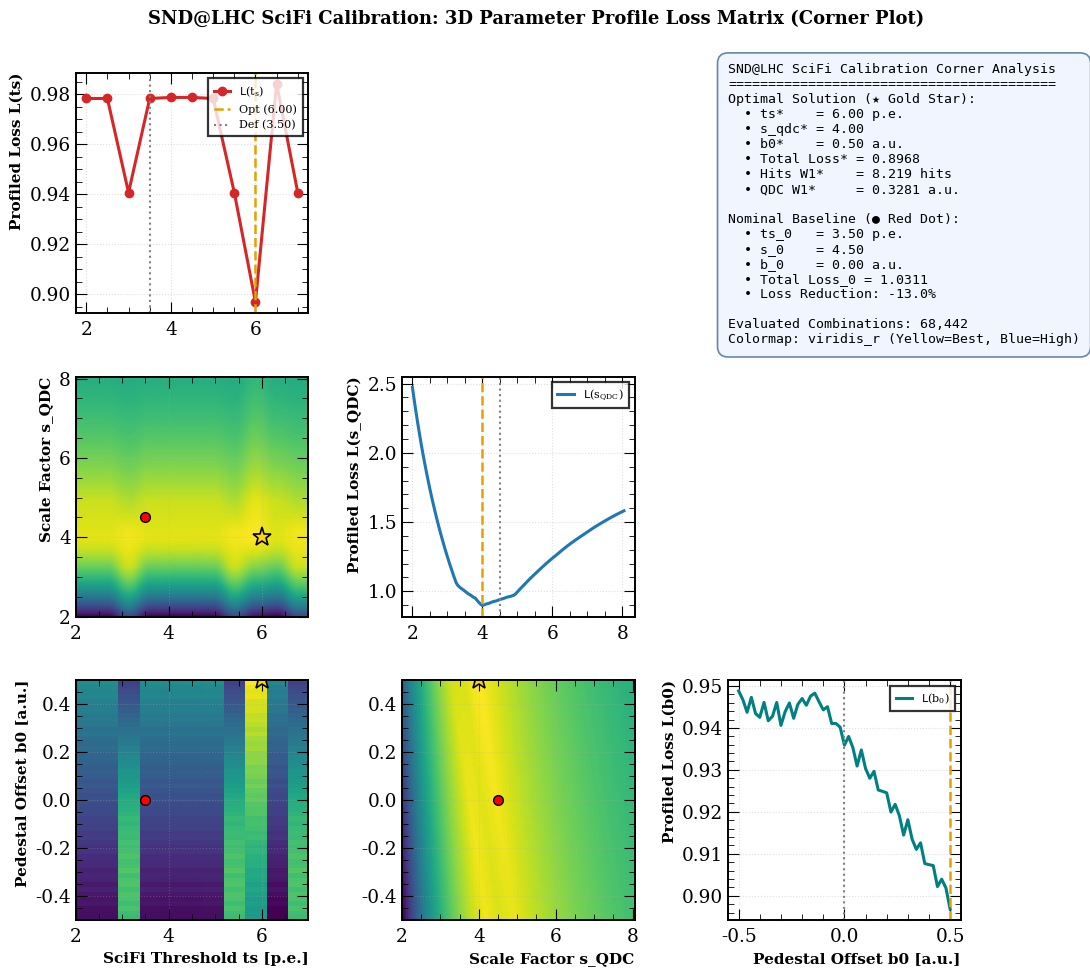

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(11, 10))

# -----------------------------------------------------------------------------
# Diagonals: 1D Profiled Marginal Loss
# -----------------------------------------------------------------------------
# 1. ts Profile
prof_ts = df_grid.groupby("ts")["total_loss"].min().reset_index()
axes[0, 0].plot(prof_ts["ts"], prof_ts["total_loss"], "o-", color="#d62728", lw=2.2, markersize=6, label=r"$\mathcal{L}(t_s)$")
axes[0, 0].axvline(best["ts"], color="#e6a100", linestyle="--", lw=1.8, label=f"Opt ({best['ts']:.2f})")
axes[0, 0].axvline(def_row["ts"], color="gray", linestyle=":", lw=1.5, label=f"Def ({def_row['ts']:.2f})")
axes[0, 0].set_ylabel("Profiled Loss L(ts)", fontsize=11, fontweight="bold")
axes[0, 0].legend(loc="upper right", frameon=True, fontsize=8, facecolor="white")
axes[0, 0].grid(True, linestyle=":", alpha=0.4)

# 2. s_qdc Profile
prof_qs = df_grid.groupby("s_qdc")["total_loss"].min().reset_index()
axes[1, 1].plot(prof_qs["s_qdc"], prof_qs["total_loss"], "-", color="#1f77b4", lw=2.2, label=r"$\mathcal{L}(s_{QDC})$")
axes[1, 1].axvline(best["s_qdc"], color="#e6a100", linestyle="--", lw=1.8)
axes[1, 1].axvline(def_row["s_qdc"], color="gray", linestyle=":", lw=1.5)
axes[1, 1].set_ylabel("Profiled Loss L(s_QDC)", fontsize=11, fontweight="bold")
axes[1, 1].legend(loc="upper right", frameon=True, fontsize=8, facecolor="white")
axes[1, 1].grid(True, linestyle=":", alpha=0.4)

# 3. b0 Profile
prof_b0 = df_grid.groupby("b0")["total_loss"].min().reset_index()
axes[2, 2].plot(prof_b0["b0"], prof_b0["total_loss"], "-", color="#008080", lw=2.2, label=r"$\mathcal{L}(b_0)$")
axes[2, 2].axvline(best["b0"], color="#e6a100", linestyle="--", lw=1.8)
axes[2, 2].axvline(def_row["b0"], color="gray", linestyle=":", lw=1.5)
axes[2, 2].set_ylabel("Profiled Loss L(b0)", fontsize=11, fontweight="bold")
axes[2, 2].set_xlabel("Pedestal Offset b0 [a.u.]", fontsize=11, fontweight="bold")
axes[2, 2].legend(loc="upper right", frameon=True, fontsize=8, facecolor="white")
axes[2, 2].grid(True, linestyle=":", alpha=0.4)

# -----------------------------------------------------------------------------
# Lower Triangle: 2D Contour & Heatmap Projections
# -----------------------------------------------------------------------------
# (Row 1, Col 0): ts vs s_qdc
p2_ts_qs = df_grid.groupby(["s_qdc", "ts"])["total_loss"].min().unstack()
im1 = axes[1, 0].imshow(
    p2_ts_qs, origin="lower", aspect="auto",
    extent=[p2_ts_qs.columns.min(), p2_ts_qs.columns.max(), p2_ts_qs.index.min(), p2_ts_qs.index.max()],
    cmap="viridis_r"
)
axes[1, 0].plot(best["ts"], best["s_qdc"], "*", color="gold", markersize=14, markeredgecolor="black", markeredgewidth=1.2)
axes[1, 0].plot(def_row["ts"], def_row["s_qdc"], "o", color="red", markersize=7, markeredgecolor="black")
axes[1, 0].set_ylabel("Scale Factor s_QDC", fontsize=11, fontweight="bold")
axes[1, 0].grid(True, linestyle=":", alpha=0.3)

# (Row 2, Col 0): ts vs b0
p2_ts_b0 = df_grid.groupby(["b0", "ts"])["total_loss"].min().unstack()
axes[2, 0].imshow(
    p2_ts_b0, origin="lower", aspect="auto",
    extent=[p2_ts_b0.columns.min(), p2_ts_b0.columns.max(), p2_ts_b0.index.min(), p2_ts_b0.index.max()],
    cmap="viridis_r"
)
axes[2, 0].plot(best["ts"], best["b0"], "*", color="gold", markersize=14, markeredgecolor="black", markeredgewidth=1.2)
axes[2, 0].plot(def_row["ts"], def_row["b0"], "o", color="red", markersize=7, markeredgecolor="black")
axes[2, 0].set_xlabel("SciFi Threshold ts [p.e.]", fontsize=11, fontweight="bold")
axes[2, 0].set_ylabel("Pedestal Offset b0 [a.u.]", fontsize=11, fontweight="bold")
axes[2, 0].grid(True, linestyle=":", alpha=0.3)

# (Row 2, Col 1): s_qdc vs b0
p2_qs_b0 = df_grid.groupby(["b0", "s_qdc"])["total_loss"].min().unstack()
axes[2, 1].imshow(
    p2_qs_b0, origin="lower", aspect="auto",
    extent=[p2_qs_b0.columns.min(), p2_qs_b0.columns.max(), p2_qs_b0.index.min(), p2_qs_b0.index.max()],
    cmap="viridis_r"
)
axes[2, 1].plot(best["s_qdc"], best["b0"], "*", color="gold", markersize=14, markeredgecolor="black", markeredgewidth=1.2)
axes[2, 1].plot(def_row["s_qdc"], def_row["b0"], "o", color="red", markersize=7, markeredgecolor="black")
axes[2, 1].set_xlabel("Scale Factor s_QDC", fontsize=11, fontweight="bold")
axes[2, 1].grid(True, linestyle=":", alpha=0.3)

# -----------------------------------------------------------------------------
# Upper Triangle: Information Summary Panel
# -----------------------------------------------------------------------------
axes[0, 1].axis("off")
axes[0, 2].axis("off")
axes[1, 2].axis("off")

info_card = (
    "SND@LHC SciFi Calibration Corner Analysis\n"
    "=========================================\n"
    f"Optimal Solution (★ Gold Star):\n"
    f"  • ts*    = {best['ts']:.2f} p.e.\n"
    f"  • s_qdc* = {best['s_qdc']:.2f}\n"
    f"  • b0*    = {best['b0']:.2f} a.u.\n"
    f"  • Total Loss* = {best['total_loss']:.4f}\n"
    f"  • Hits W1*    = {best['w1_hits']:.3f} hits\n"
    f"  • QDC W1*     = {best['w1_qdc']:.4f} a.u.\n\n"
    f"Nominal Baseline (● Red Dot):\n"
    f"  • ts_0   = {def_row['ts']:.2f} p.e.\n"
    f"  • s_0    = {def_row['s_qdc']:.2f}\n"
    f"  • b_0    = {def_row['b0']:.2f} a.u.\n"
    f"  • Total Loss_0 = {def_row['total_loss']:.4f}\n"
    f"  • Loss Reduction: -{((def_row['total_loss']-best['total_loss'])/def_row['total_loss'])*100:.1f}%\n\n"
    f"Evaluated Combinations: {len(df_grid):,}\n"
    "Colormap: viridis_r (Yellow=Best, Blue=High)"
)

axes[0, 2].text(
    0.0, 0.45, info_card, transform=axes[0, 2].transAxes, fontsize=9.5,
    verticalalignment="center", fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.8", facecolor="#f0f5ff", edgecolor="#5c82a6", alpha=0.95, lw=1.2)
)

plt.suptitle("SND@LHC SciFi Calibration: 3D Parameter Profile Loss Matrix (Corner Plot)", fontsize=13, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()


### 5. Visualization Paradigm 2: Multi-Slice "Tomography" (Small Multiples)
Because $(s_{\text{QDC}}, b_0)$ are coupled via the linear transformation $x_{\text{calib}} = (x_{\text{raw}} - b_0) / s_{\text{QDC}}$, the optimal scale factor $s_{\text{QDC}}^*$ depends strongly on the pedestal offset $b_0$.

**Multi-Slice Tomography** slices the 3D space along the continuous offset axis at 5 discrete levels:
$$b_0 \in \{-0.40, -0.20, 0.00, +0.20, +0.40\}\ \text{a.u.}$$
Each small multiple displays the 2D surface $\mathcal{L}(t_s, s_{\text{QDC}})$ with a **shared global color scale**, enabling direct visual comparison of how the minimum translates across slices.


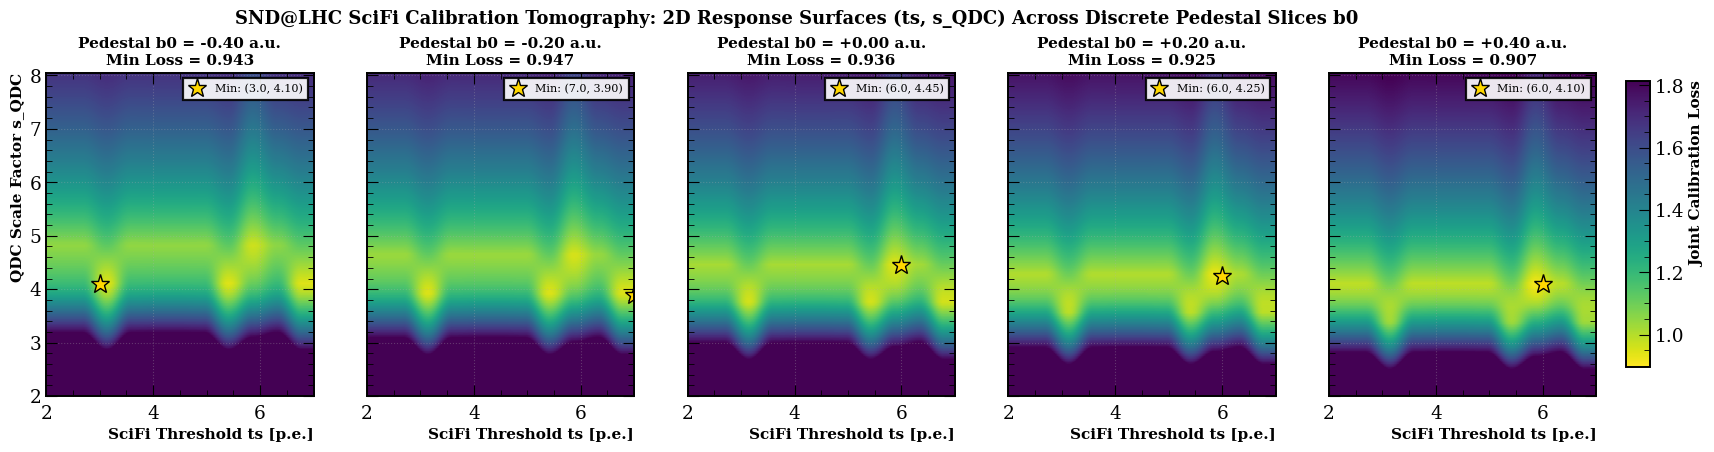

In [5]:
b0_slices = [-0.4, -0.2, 0.0, 0.2, 0.4]
fig, axes = plt.subplots(1, 5, figsize=(20, 4.2), sharey=True)

# Shared colorbar range across all panels
sub_df = df_grid[df_grid["b0"].isin(b0_slices)]
vmin = df_grid["total_loss"].min()
vmax = np.percentile(sub_df["total_loss"], 85)

for idx, (b_val, ax) in enumerate(zip(b0_slices, axes)):
    slice_data = df_grid[abs(df_grid["b0"] - b_val) < 1e-4]
    p = slice_data.groupby(["s_qdc", "ts"])["total_loss"].min().unstack()

    im = ax.imshow(
        p, origin="lower", aspect="auto",
        extent=[p.columns.min(), p.columns.max(), p.index.min(), p.index.max()],
        cmap="viridis_r", vmin=vmin, vmax=vmax
    )

    local_best = slice_data.sort_values("total_loss").iloc[0]
    ax.plot(
        local_best["ts"], local_best["s_qdc"], "*", color="gold", markersize=14, markeredgecolor="black",
        label=f"Min: ({local_best['ts']:.1f}, {local_best['s_qdc']:.2f})"
    )

    ax.set_title(f"Pedestal b0 = {b_val:+.2f} a.u.\nMin Loss = {local_best['total_loss']:.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("SciFi Threshold ts [p.e.]", fontsize=11, fontweight="bold")
    if idx == 0:
        ax.set_ylabel("QDC Scale Factor s_QDC", fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", frameon=True, fontsize=8, facecolor="white", framealpha=0.9)
    ax.grid(True, linestyle=":", alpha=0.3)

# Global unified colorbar
cbar_ax = fig.add_axes([0.915, 0.18, 0.012, 0.68])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Joint Calibration Loss", fontsize=11, fontweight="bold")

plt.suptitle(
    "SND@LHC SciFi Calibration Tomography: 2D Response Surfaces (ts, s_QDC) Across Discrete Pedestal Slices b0",
    fontsize=13, fontweight="bold", y=1.03
)
plt.show()


### 6. Visualization Paradigm 3: Multi-Objective Pareto Frontier Analysis
Calibration requires simultaneous optimization of two competing physical observables:
1. **Hit Multiplicity Discrepancy**: $W_1^{\text{hits}}$ [hits].
2. **QDC Energy Scale Discrepancy**: $W_1^{\text{QDC}}$ [a.u.].

A configuration $\boldsymbol{\theta}_A$ **Pareto-dominates** $\boldsymbol{\theta}_B$ if:
$$W_1^{\text{hits}}(\boldsymbol{\theta}_A) \le W_1^{\text{hits}}(\boldsymbol{\theta}_B) \quad \text{and} \quad W_1^{\text{QDC}}(\boldsymbol{\theta}_A) \le W_1^{\text{QDC}}(\boldsymbol{\theta}_B)$$
with at least one strict inequality.
The **Pareto Frontier** represents the non-dominated envelope of optimal compromise solutions. No solution along the frontier can improve hit multiplicity without sacrificing energy scale accuracy, and vice versa.


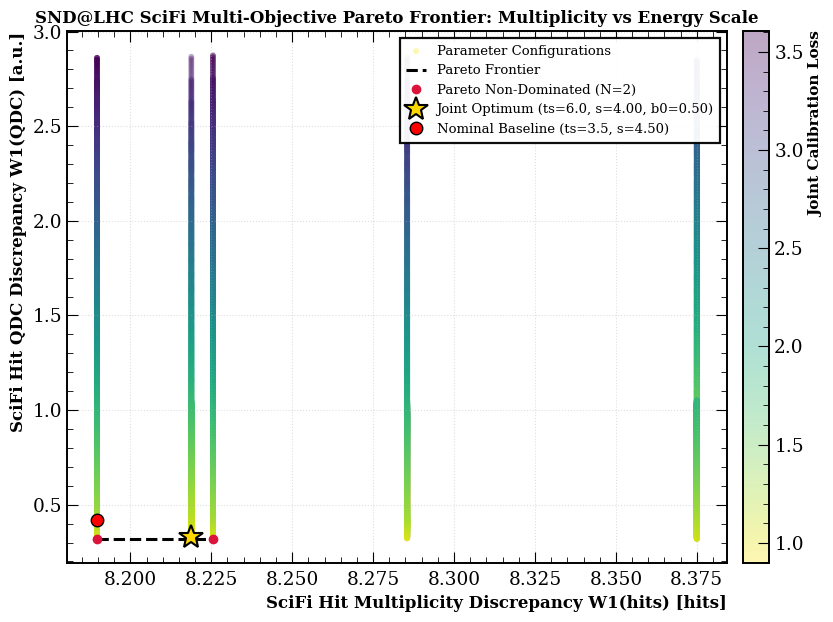

In [6]:
fig, ax = plt.subplots(figsize=(9, 6.5))

# Compute Non-Dominated Pareto Frontier Points
df_sorted = df_grid.sort_values(["w1_hits", "w1_qdc"]).reset_index(drop=True)
pareto_points = []
min_y = float("inf")
for idx, row in df_sorted.iterrows():
    if row["w1_qdc"] < min_y:
        pareto_points.append(row)
        min_y = row["w1_qdc"]

pareto_df = pd.DataFrame(pareto_points)

# Scatter plot of full parameter ensemble colored by composite loss
scatter = ax.scatter(
    df_grid["w1_hits"], df_grid["w1_qdc"], c=df_grid["total_loss"], cmap="viridis_r",
    s=18, alpha=0.35, edgecolors="none", label="Parameter Configurations"
)
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Joint Calibration Loss", fontsize=11, fontweight="bold")

# Trace Pareto Optimal Frontier
ax.step(pareto_df["w1_hits"], pareto_df["w1_qdc"], where="post", color="black", lw=2.2, linestyle="--", label="Pareto Frontier")
ax.plot(pareto_df["w1_hits"], pareto_df["w1_qdc"], "o", color="crimson", markersize=6, label=f"Pareto Non-Dominated (N={len(pareto_df)})")

# Mark Balanced Global Optimum
ax.plot(
    best["w1_hits"], best["w1_qdc"], "*", color="gold", markersize=18, markeredgecolor="black", markeredgewidth=1.5,
    label=f"Joint Optimum (ts={best['ts']:.1f}, s={best['s_qdc']:.2f}, b0={best['b0']:.2f})"
)

# Mark Nominal Default Baseline
ax.plot(
    def_row["w1_hits"], def_row["w1_qdc"], "o", color="red", markersize=9, markeredgecolor="black",
    label=f"Nominal Baseline (ts={def_row['ts']:.1f}, s={def_row['s_qdc']:.2f})"
)

ax.set_xlabel("SciFi Hit Multiplicity Discrepancy W1(hits) [hits]", fontsize=12, fontweight="bold")
ax.set_ylabel("SciFi Hit QDC Discrepancy W1(QDC) [a.u.]", fontsize=12, fontweight="bold")
ax.set_title("SND@LHC SciFi Multi-Objective Pareto Frontier: Multiplicity vs Energy Scale", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", frameon=True, fontsize=9.5, facecolor="white", framealpha=0.95)
ax.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()


### 7. Visualization Paradigm 4: Parallel Coordinates Trajectory Flow
To visualize complete multi-dimensional trajectories connecting all inputs $(t_s, s_{\text{QDC}}, b_0)$ to outputs $(W_1^{\text{hits}}, W_1^{\text{QDC}}, \mathcal{L}_{\text{total}})$, we plot **Parallel Coordinates**:
- Each configuration forms a continuous polygonal path crossing 6 parallel vertical coordinate axes.
- Background gray trajectories represent a random sample of 1,500 grid points.
- Foreground colored lines show the **top 100 best configurations**, revealing which parameter paths successfully funnel into minimal loss values.
- The global optimum is highlighted with a gold line and star markers; the nominal default is shown in dashed red.


/tmp/ipykernel_675874/1119277840.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis_r")


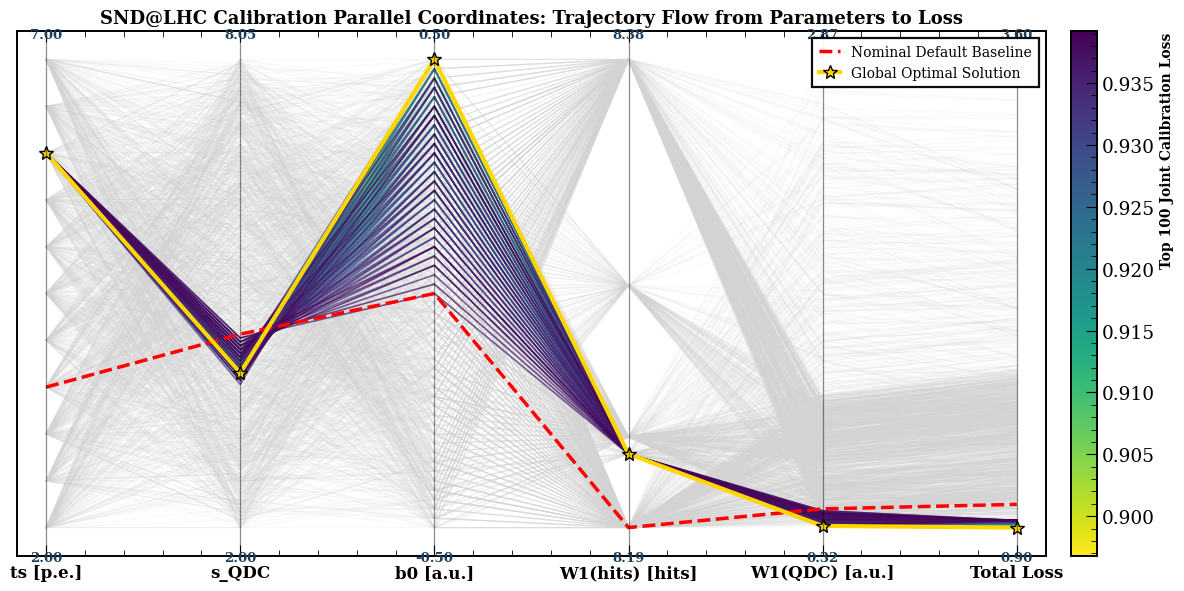

In [7]:
cols = ["ts", "s_qdc", "b0", "w1_hits", "w1_qdc", "total_loss"]
col_labels = [
    "ts [p.e.]",
    "s_QDC",
    "b0 [a.u.]",
    "W1(hits) [hits]",
    "W1(QDC) [a.u.]",
    "Total Loss"
]

fig, ax = plt.subplots(figsize=(13, 6.2))

mins = df_grid[cols].min()
maxs = df_grid[cols].max()

def normalize_row(row):
    return (row[cols] - mins) / (maxs - mins)

# Top 100 best configurations
top_100 = df_grid.head(100).copy()
cmap = plt.cm.get_cmap("viridis_r")
norm_loss = plt.Normalize(vmin=top_100["total_loss"].min(), vmax=top_100["total_loss"].max())
x_axes = list(range(len(cols)))

# Subsample background ensemble for visual context
bg_sample = df_grid.sample(min(1500, len(df_grid)), random_state=42)
for _, r in bg_sample.iterrows():
    y = normalize_row(r)
    ax.plot(x_axes, y, color="lightgray", alpha=0.15, lw=0.8)

# Foreground top 100 trajectories
for _, r in top_100.iterrows():
    y = normalize_row(r)
    color = cmap(norm_loss(r["total_loss"]))
    ax.plot(x_axes, y, color=color, alpha=0.7, lw=1.2)

# Nominal Default baseline
y_def = normalize_row(def_row)
ax.plot(x_axes, y_def, color="red", linestyle="--", lw=2.5, label="Nominal Default Baseline")

# Global Optimum
y_best = normalize_row(best)
ax.plot(x_axes, y_best, color="gold", linestyle="-", lw=3.0, marker="*", markersize=10, markeredgecolor="black", label="Global Optimal Solution")

# Axes configuration
ax.set_xticks(x_axes)
ax.set_xticklabels(col_labels, fontsize=12, fontweight="bold")
ax.set_yticks([])
ax.set_xlim(-0.15, len(cols) - 0.85)
ax.set_ylim(-0.06, 1.06)

# Physical unit bounds at axis limits
for i, col in enumerate(cols):
    ax.text(i, -0.05, f"{mins[col]:.2f}", ha="center", va="top", fontsize=9.5, fontweight="bold", color="#1c3d5a")
    ax.text(i, 1.04, f"{maxs[col]:.2f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold", color="#1c3d5a")
    ax.axvline(i, color="black", linestyle="-", lw=0.9, alpha=0.45)

ax.set_title("SND@LHC Calibration Parallel Coordinates: Trajectory Flow from Parameters to Loss", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", frameon=True, fontsize=10, facecolor="white", framealpha=0.95)

# Colorbar for top 100 solutions
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_loss)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Top 100 Joint Calibration Loss", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


### 8. Visualization Paradigm 5: Calibrated Physical Distribution Overlays
Finally, we compare the physical distributions of the **Collision Data Reference** against the **Nominal Default Simulation** and the **Optimally Calibrated Simulation**:
1. **SciFi Hit Multiplicity (Panel A)**: Valid hits across 10 tracking planes, with MC / Data ratio pulls.
2. **SciFi Hit QDC Energy Scale (Panel B)**: Single-hit digitized charge (MIP Landau-Gaussian peak), with MC / Data ratio pulls.


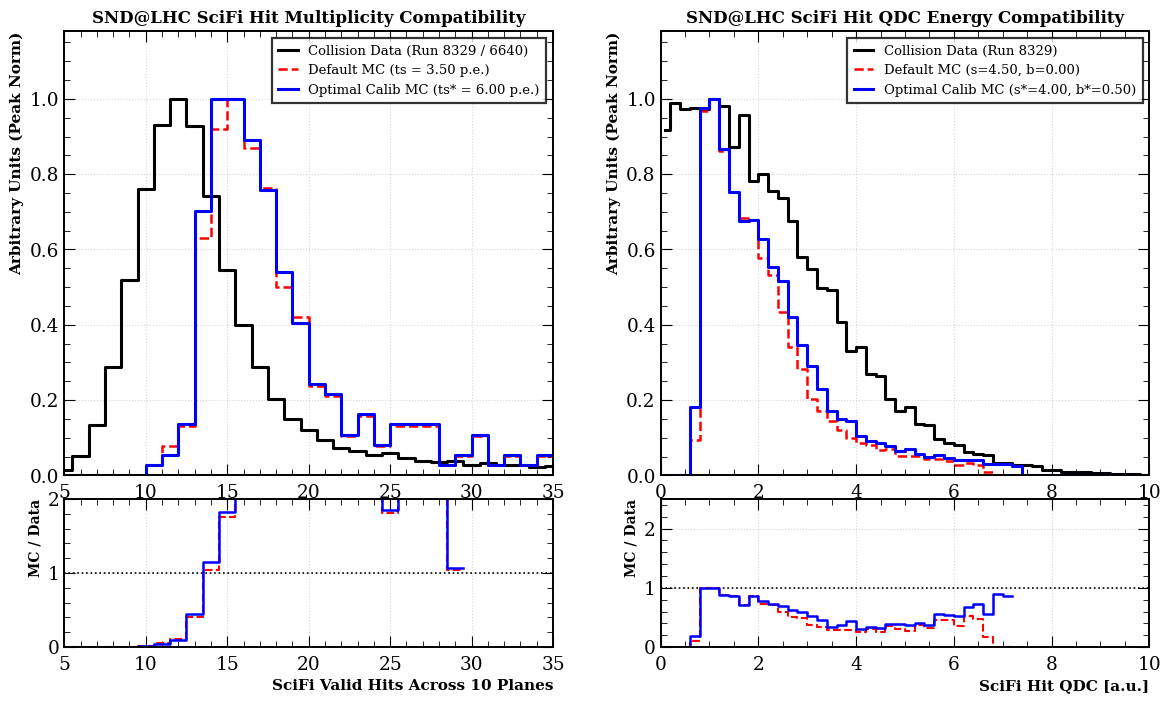

In [8]:
fig, ((ax_h_top, ax_q_top), (ax_h_bot, ax_q_bot)) = plt.subplots(
    2, 2, figsize=(14, 8),
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08, 'wspace': 0.22}
)

# -----------------------------------------------------------------------------
# PANEL A: SciFi Hit Multiplicity
# -----------------------------------------------------------------------------
# Collision Data
norm_dh = counts_dh / np.max(counts_dh) if np.max(counts_dh) > 0 else counts_dh
x_dh_centers = np.array([h_data_hits.GetBinCenter(i) for i in range(1, nbins_dh + 1)])
ax_h_top.step(x_dh_centers, norm_dh, where='mid', label="Collision Data (Run 8329 / 6640)", color="black", lw=2.2)

# Default Simulation
h_h_def = mc_cache[def_row["ts"]]["h_hits"]
c_mh_def = np.array([h_h_def.GetBinContent(i) for i in range(1, h_h_def.GetNbinsX() + 1)])
x_mh_def = np.array([h_h_def.GetBinCenter(i) for i in range(1, h_h_def.GetNbinsX() + 1)])
norm_mh_def = c_mh_def / np.max(c_mh_def) if np.max(c_mh_def) > 0 else c_mh_def
ax_h_top.step(x_mh_def, norm_mh_def, where='mid', label=f"Default MC (ts = {def_row['ts']:.2f} p.e.)", color="red", linestyle="--", lw=1.8)

# Optimal Simulation
h_h_best = mc_cache[best["ts"]]["h_hits"]
c_mh_best = np.array([h_h_best.GetBinContent(i) for i in range(1, h_h_best.GetNbinsX() + 1)])
x_mh_best = np.array([h_h_best.GetBinCenter(i) for i in range(1, h_h_best.GetNbinsX() + 1)])
norm_mh_best = c_mh_best / np.max(c_mh_best) if np.max(c_mh_best) > 0 else c_mh_best
ax_h_top.step(x_mh_best, norm_mh_best, where='mid', label=f"Optimal Calib MC (ts* = {best['ts']:.2f} p.e.)", color="blue", lw=2.2)

ax_h_top.set_xlim(5, 35)
ax_h_top.set_ylim(0, 1.18)
ax_h_top.set_ylabel("Arbitrary Units (Peak Norm)", fontsize=11, fontweight="bold")
ax_h_top.set_title("SND@LHC SciFi Hit Multiplicity Compatibility", fontsize=12, fontweight="bold")
ax_h_top.legend(loc="upper right", frameon=True, fontsize=9.5)
ax_h_top.grid(True, linestyle=":", alpha=0.5)

# Ratio Panel A
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_def_h = np.where(norm_dh > 0.03, np.interp(x_dh_centers, x_mh_def, norm_mh_def) / norm_dh, np.nan)
    ratio_best_h = np.where(norm_dh > 0.03, np.interp(x_dh_centers, x_mh_best, norm_mh_best) / norm_dh, np.nan)

ax_h_bot.axhline(1.0, color="black", linestyle=":", lw=1.2)
ax_h_bot.step(x_dh_centers, ratio_def_h, where='mid', color="red", linestyle="--", lw=1.5)
ax_h_bot.step(x_dh_centers, ratio_best_h, where='mid', color="blue", lw=1.8)
ax_h_bot.set_xlim(5, 35)
ax_h_bot.set_ylim(0.0, 2.0)
ax_h_bot.set_ylabel("MC / Data", fontsize=10, fontweight="bold")
ax_h_bot.set_xlabel("SciFi Valid Hits Across 10 Planes", fontsize=11, fontweight="bold")
ax_h_bot.grid(True, linestyle=":", alpha=0.5)

# -----------------------------------------------------------------------------
# PANEL B: SciFi Hit QDC Distribution
# -----------------------------------------------------------------------------
norm_dq = counts_dq / np.max(counts_dq) if np.max(counts_dq) > 0 else counts_dq
x_dq_centers = np.array([h_data_qdc.GetBinCenter(i) for i in range(1, nbins_dq + 1)])
ax_q_top.step(x_dq_centers, norm_dq, where='mid', label="Collision Data (Run 8329)", color="black", lw=2.2)

# Default MC QDC rescaled
c_def = mc_cache[def_row["ts"]]
x_scaled_def = (c_def["x_edges_mq"] - def_row["b0"]) / def_row["s_qdc"]
cdf_def = np.interp(x_edges_dq, x_scaled_def, c_def["cdf_mq_raw"], left=0.0, right=1.0)
pdf_def = np.diff(cdf_def)
norm_mq_def = pdf_def / np.max(pdf_def) if np.max(pdf_def) > 0 else pdf_def
ax_q_top.step(x_dq_centers, norm_mq_def, where='mid', label=f"Default MC (s={def_row['s_qdc']:.2f}, b={def_row['b0']:.2f})", color="red", linestyle="--", lw=1.8)

# Optimal MC QDC rescaled
c_best = mc_cache[best["ts"]]
x_scaled_best = (c_best["x_edges_mq"] - best["b0"]) / best["s_qdc"]
cdf_best = np.interp(x_edges_dq, x_scaled_best, c_best["cdf_mq_raw"], left=0.0, right=1.0)
pdf_best = np.diff(cdf_best)
norm_mq_best = pdf_best / np.max(pdf_best) if np.max(pdf_best) > 0 else pdf_best
ax_q_top.step(x_dq_centers, norm_mq_best, where='mid', label=f"Optimal Calib MC (s*={best['s_qdc']:.2f}, b*={best['b0']:.2f})", color="blue", lw=2.2)

ax_q_top.set_xlim(0, 10)
ax_q_top.set_ylim(0, 1.18)
ax_q_top.set_ylabel("Arbitrary Units (Peak Norm)", fontsize=11, fontweight="bold")
ax_q_top.set_title("SND@LHC SciFi Hit QDC Energy Compatibility", fontsize=12, fontweight="bold")
ax_q_top.legend(loc="upper right", frameon=True, fontsize=9.5)
ax_q_top.grid(True, linestyle=":", alpha=0.5)

# Ratio Panel B
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_def_q = np.where(norm_dq > 0.03, norm_mq_def / norm_dq, np.nan)
    ratio_best_q = np.where(norm_dq > 0.03, norm_mq_best / norm_dq, np.nan)

ax_q_bot.axhline(1.0, color="black", linestyle=":", lw=1.2)
ax_q_bot.step(x_dq_centers, ratio_def_q, where='mid', color="red", linestyle="--", lw=1.5)
ax_q_bot.step(x_dq_centers, ratio_best_q, where='mid', color="blue", lw=1.8)
ax_q_bot.set_xlim(0, 10)
ax_q_bot.set_ylim(0.0, 2.5)
ax_q_bot.set_ylabel("MC / Data", fontsize=10, fontweight="bold")
ax_q_bot.set_xlabel("SciFi Hit QDC [a.u.]", fontsize=11, fontweight="bold")
ax_q_bot.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


### 9. Interactive Calibration Explorer Widget
Use the sliders below to dynamically adjust $(t_s, s_{\text{QDC}}, b_0)$ and observe the real-time response of the calibrated simulation against collision data.
*(Note: Requires an active Jupyter/ipywidgets session)*.


In [9]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact

    available_ts = sorted(list(mc_cache.keys()))

    def live_calibration_view(ts=best["ts"], s_qdc=best["s_qdc"], b0=best["b0"]):
        c = mc_cache[ts]
        x_scaled = (c["x_edges_mq"] - b0) / s_qdc
        cdf_on_d = np.interp(x_edges_dq, x_scaled, c["cdf_mq_raw"], left=0.0, right=1.0)
        cdf_centers = 0.5 * (cdf_on_d[:-1] + cdf_on_d[1:])
        w1_q = float(np.sum(np.abs(cdf_dq - cdf_centers)) * dx_dq)
        pdf = np.diff(cdf_on_d)
        norm_pdf = pdf / np.max(pdf) if np.max(pdf) > 0 else pdf

        peak_q = (c["raw_peak_q"] - b0) / s_qdc
        loss_q = (w1_q / mean_data_qdc) + (abs(peak_q - peak_data_qdc) / peak_data_qdc)
        total_l = c["loss_hits"] + loss_q

        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.step(x_dq_centers, norm_dq, where='mid', label="Collision Data", color="black", lw=2.2)
        ax.step(x_dq_centers, norm_pdf, where='mid', label=f"Calibrated MC (ts={ts:.1f}, s={s_qdc:.2f}, b0={b0:.2f})", color="royalblue", lw=2.0)
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 1.15)
        ax.set_xlabel("SciFi Hit QDC [a.u.]", fontsize=11, fontweight="bold")
        ax.set_ylabel("Peak-Normalized Yield", fontsize=11, fontweight="bold")
        ax.set_title(f"Dynamic Calibration Inspection: W1(QDC) = {w1_q:.3f} a.u. | Loss = {total_l:.4f}", fontsize=11, fontweight="bold")
        ax.legend(loc="upper right", frameon=True, fontsize=9.5)
        ax.grid(True, linestyle=":", alpha=0.4)
        plt.tight_layout()
        plt.show()

    interact(
        live_calibration_view,
        ts=widgets.Dropdown(options=available_ts, value=best["ts"], description="ts [p.e.]:"),
        s_qdc=widgets.FloatSlider(min=2.0, max=8.0, step=0.1, value=best["s_qdc"], description="s_QDC:"),
        b0=widgets.FloatSlider(min=-0.5, max=0.5, step=0.05, value=best["b0"], description="b0 [a.u.]:")
    )
except Exception as e:
    print(f"Interactive widget unavailable in static environment: {e}")


interactive(children=(Dropdown(description='ts [p.e.]:', index=8, options=(2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, …